calling
first run


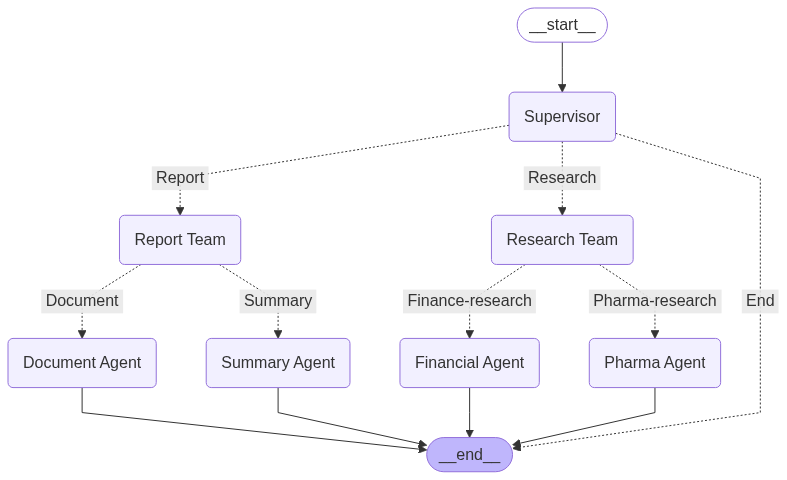

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.tools import tool
import operator
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles


class AgenticState(TypedDict):
    state: Annotated[ Sequence[BaseMessage], operator.add]

class GraphBuilder:
    def __init__(self):
        self.graph = None

    def router_to_teams(self):pass
    def router_to_research_tool(self): pass
    def router_to_report_tool(self): pass

    def supervisor_node(self, state): pass

    def research_team_node(self, state): pass

    def report_team_node(self, state): pass

    @tool
    def pharma_agent_node(self, state):
        """
        """
        pass

    @tool
    def financial_agent_node(self, state):
        """
        """
        pass

    @tool
    def summary_agent_node(self, state):
        """
        """
        pass

    @tool
    def document_agent_node(self, state):
        """
        """
        pass

    def build_graph(self):
        graph_builder = StateGraph(AgenticState)
        
        # Add nodes
        graph_builder.add_node("Supervisor", self.supervisor_node)
        graph_builder.add_node("Research Team", self.research_team_node)
        graph_builder.add_node("Report Team", self.report_team_node)
        graph_builder.add_node("Pharma Agent", self.pharma_agent_node)
        graph_builder.add_node("Financial Agent", self.financial_agent_node)
        graph_builder.add_node("Summary Agent", self.summary_agent_node)
        graph_builder.add_node("Document Agent", self.document_agent_node)

        tools = []

        # Add edges
        graph_builder.add_conditional_edges(
            "Supervisor",
            self.router_to_teams,
            {
                "Research": "Research Team",
                "Report": "Report Team",
                "End": END
            }
        )
        graph_builder.add_conditional_edges(
            "Research Team",
            self.router_to_research_tool,
            {
                "Pharma-research":  "Pharma Agent",
                "Finance-research": "Financial Agent"
            }
        )
        graph_builder.add_conditional_edges(
            "Report Team",
            self.router_to_report_tool,
            {
                "Summary":  "Summary Agent",
                "Document": "Document Agent"
            }
        )

        # Entry point and Exit point
        graph_builder.add_edge(START, "Supervisor")
        graph_builder.add_edge("Supervisor", END)

        # Compile
        print("first run")
        self.graph = graph_builder.compile()

        return self.graph
    
    def __call__(self, *args, **kwds):
        print("calling")
        graph = self.build_graph()
        print(graph)
        # graph.get_graph().get_graphviz().render("graph_output", format="png")
        # graph.get_graph().draw_png("graph_output")
        try:
            display(Image(graph.get_graph().draw_mermaid_png()))
        except Exception as e:
            print(e)
        return graph
    

if __name__ == "__main__":
    g = GraphBuilder()
    g()



